# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [3]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')

## 모듈 import

In [4]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler, Job
# 향후 알고리즘 모듈 추가 예정
# from algorithms.genetic import GeneticScheduler
# from algorithms.rule_based import RuleBasedScheduler

## 데이터 로드

In [5]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개


## 시뮬레이션 실행

In [6]:
# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(
    env=env,
    machine_df=data['machines'],
    operations_df=data['operations'],
    machine_failure_df=data['machine_failure'],
    setup_times_df=data['setup_times'],
    op_machine_df=data['operation_machine_map'],
    event_logger=event_logger
)

## 작업 생성

In [7]:
jobs = []
for _, job_info in data['jobs'].iterrows():
    # 해당 작업의 operation 정보 가져오기
    job_operations = data['operations'].loc[
        data['operations']['job_id'] == job_info['job_id'],
        ['op_id', 'op_seq', 'qtime']
    ].sort_values('op_seq')
    
    # Job 인스턴스 생성
    job = Job(
        env=env,
        job_info=job_info.to_dict(),
        op_info=job_operations,
        scheduler=scheduler,
        event_logger=event_logger
    )
    jobs.append(job)

## 시뮬레이션 실행

In [10]:
env.run(until=env.all_of(job.process for job in jobs))
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 시뮬레이션 KPI 및 통계

### 작업별 통계

In [7]:
df_logs = pd.DataFrame(event_logger.logs)
completed_cnt = 0
completed_in_due_date = 0
total_qtime_violation = 0.0
for job in jobs:
    print(f"Job ID: {job.id}, QTime Violation: {round(job.calculate_qtime_over(env.now), 3)}")
    completed_cnt += int(job.is_completed)
    completed_in_due_date = int(job.is_in_due_date())
    total_qtime_violation += job.total_qtime_over
print(f"총 작업 수: {len(jobs)}\n완료된 작업 수: {completed_cnt}\n기한 안에 완료된 작업 수: {completed_in_due_date}\n총 QTime 위반 시간: {round(total_qtime_violation, 3)}")
# 향후 결과 분석 기능 추가
# - 평균 대기 시간
# - 장비 가동률

Job ID: J01, QTime Violation: 5.0
Job ID: J02, QTime Violation: 0.0
Job ID: J03, QTime Violation: 0.0
Job ID: J04, QTime Violation: 0.0
Job ID: J05, QTime Violation: 0.0
Job ID: J06, QTime Violation: 0.0
Job ID: J07, QTime Violation: 7.823
Job ID: J08, QTime Violation: 6.369
Job ID: J09, QTime Violation: 7.631
Job ID: J10, QTime Violation: 0.0
총 작업 수: 10
완료된 작업 수: 4
기한 안에 완료된 작업 수: 0
총 QTime 위반 시간: 26.823

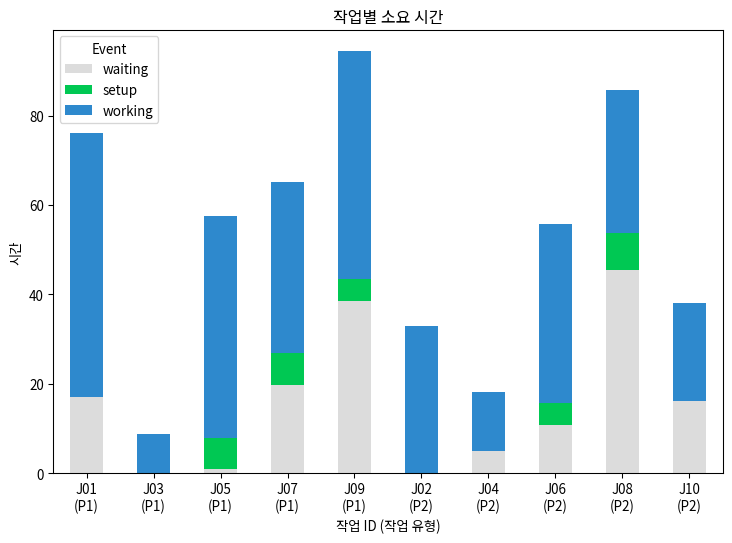

In [8]:
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
display(job_stacked)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
job_stacked.plot(kind='bar', stacked=True, figsize=(9, 6), color={
    "waiting": '#DCDCDC',
    "setup": '#00C853',
    "working": '#2E89CD'
})
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.xticks(rotation=0)
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

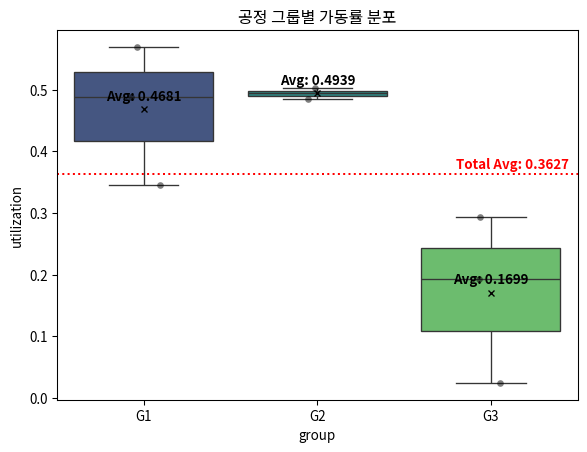

In [9]:
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()